# Proyecto 5

## Objetivo:
Implementar un algoritmo de optimización por colonia de hormigas (ACO) para encontrar el camino óptimo entre el inicio y la salida de un laberinto, utilizando un modelo basado en feromonas y heurísticas de distancia que permita observar el comportamiento colectivo emergente de la colonia.

In [5]:
import random
import math

In [6]:
laberinto = [
    [1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 1, 1, 0, 1, 0, 0, 1, 0 ,1, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1, 1, 0 ,1, 1, 1, 0, 1, 1, 1, 1],
    [0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0 ,0 ,0 ,1],
    [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
]

def laberinto_a_grafo(lab):
    grafo = {}
    filas = len(lab)
    columnas = len(lab[0])

    for i in range(filas):
        for j in range(columnas):
            if lab[i][j] == 1:
                nodo = (i, j)
                grafo[nodo] = {}

                vecinos = [
                    (i-1, j),
                    (i+1, j),
                    (i, j-1),
                    (i, j+1)
                ]

                for (x, y) in vecinos:
                    if 0 <= x < filas and 0 <= y < columnas:
                        if lab[x][y] == 1:
                            grafo[nodo][(x, y)] = 1

    return grafo

grafo = laberinto_a_grafo(laberinto)
grafo

{(0, 0): {(1, 0): 1},
 (0, 4): {(1, 4): 1, (0, 5): 1},
 (0, 5): {(0, 4): 1, (0, 6): 1},
 (0, 6): {(0, 5): 1, (0, 7): 1},
 (0, 7): {(1, 7): 1, (0, 6): 1},
 (0, 9): {(1, 9): 1, (0, 10): 1},
 (0, 10): {(0, 9): 1, (0, 11): 1},
 (0, 11): {(1, 11): 1, (0, 10): 1},
 (0, 13): {(1, 13): 1, (0, 14): 1},
 (0, 14): {(0, 13): 1},
 (1, 0): {(0, 0): 1, (1, 1): 1},
 (1, 1): {(1, 0): 1, (1, 2): 1},
 (1, 2): {(2, 2): 1, (1, 1): 1},
 (1, 4): {(0, 4): 1, (2, 4): 1},
 (1, 7): {(0, 7): 1, (2, 7): 1},
 (1, 9): {(0, 9): 1, (2, 9): 1},
 (1, 11): {(0, 11): 1, (2, 11): 1},
 (1, 13): {(0, 13): 1, (2, 13): 1},
 (2, 2): {(1, 2): 1, (3, 2): 1},
 (2, 4): {(1, 4): 1, (2, 5): 1},
 (2, 5): {(3, 5): 1, (2, 4): 1},
 (2, 7): {(1, 7): 1, (2, 8): 1},
 (2, 8): {(2, 7): 1, (2, 9): 1},
 (2, 9): {(1, 9): 1, (3, 9): 1, (2, 8): 1},
 (2, 11): {(1, 11): 1, (2, 12): 1},
 (2, 12): {(2, 11): 1, (2, 13): 1},
 (2, 13): {(1, 13): 1, (2, 12): 1, (2, 14): 1},
 (2, 14): {(3, 14): 1, (2, 13): 1},
 (3, 1): {(4, 1): 1, (3, 2): 1},
 (3, 2): {(2,

In [7]:
# --- 1. PARÁMETROS DEL PROBLEMA ---
GRAFO_DISTANCIAS = grafo
NODO_INICIO = (0, 0)
NODO_FINAL = (14, 14)
TODOS_NODOS = list(GRAFO_DISTANCIAS.keys())
NUM_NODOS = len(TODOS_NODOS)

# --- 2. PARÁMETROS ACO ---
NUM_HORMIGAS = 2
NUM_ITERACIONES = 10
RHO = 0.01       # Tasa de evaporación
Q = 1.0          # Constante de depósito de feromona
ALFA = 1.0       # Influencia del rastro de feromona
BETA = 1.0       # Influencia de la heurística (visibilidad)

# --- 3. FUNCIONES PRINCIPALES ---

def inicializar_feromonas(grafo):
    feromonas = {}
    for i in grafo:
        feromonas[i] = {}
        for j in grafo[i]:
            feromonas[i][j] = 0.1  # valor inicial
    return feromonas


def probabilidad_movimiento(actual, nodos_no_visitados, feromonas, grafo, alpha, beta):
    total = 0.0
    probabilidades = {}

    # Calcula el denominador (la suma de todos los pesos posibles)
    for siguiente in nodos_no_visitados:
        if siguiente in grafo[actual]:
            tau = feromonas[actual][siguiente]
            eta = 1.0 / grafo[actual][siguiente]
            total += (tau ** alpha) * (eta ** beta)

    # Calcula la probabilidad normalizada para cada destino
    for siguiente in nodos_no_visitados:
        if siguiente in grafo[actual]:
            tau = feromonas[actual][siguiente]
            eta = 1.0 / grafo[actual][siguiente]
            prob = ((tau ** alpha) * (eta ** beta)) / total
            probabilidades[siguiente] = prob

    return probabilidades


def seleccionar_nodo(probabilidades):
    r = random.random()
    acumulada = 0.0
    for nodo, prob in probabilidades.items():
        acumulada += prob
        if r <= acumulada:
            return nodo
    # Si por redondeo no se elige ninguno
    return list(probabilidades.keys())[-1]


def construir_ruta(feromonas, grafo, alpha, beta):
    ruta = [NODO_INICIO]
    actual = NODO_INICIO
    nodos_no_visitados = TODOS_NODOS.copy()
    nodos_no_visitados.remove(actual)

    while actual != NODO_FINAL and len(nodos_no_visitados) > 0:
        probabilidades = probabilidad_movimiento(actual, nodos_no_visitados, feromonas, grafo, alpha, beta)
        if not probabilidades:
            break
        siguiente = seleccionar_nodo(probabilidades)
        ruta.append(siguiente)
        actual = siguiente
        if siguiente in nodos_no_visitados:
            nodos_no_visitados.remove(siguiente)

    return ruta


def calcular_longitud_ruta(ruta, grafo):
    distancia = 0.0
    for i in range(len(ruta) - 1):
        a, b = ruta[i], ruta[i+1]
        if b in grafo[a]:
            distancia += grafo[a][b]
        else:
            # Si no existe conexión directa, penalizamos
            distancia += 9999
    return distancia


def actualizar_feromonas(feromonas, rutas, distancias, rho, q):
    # Evaporación
    for i in feromonas:
        for j in feromonas[i]:
            feromonas[i][j] *= (1 - rho)

    # Deposito de feromonas
    for k in range(len(rutas)):
        ruta = rutas[k]
        dist = distancias[k]
        for i in range(len(ruta) - 1):
            a, b = ruta[i], ruta[i+1]
            if b in feromonas[a]:
                feromonas[a][b] += q / dist


def aco():
    feromonas = inicializar_feromonas(GRAFO_DISTANCIAS)
    mejor_ruta = None
    mejor_distancia = math.inf

    for iteracion in range(NUM_ITERACIONES):
        rutas = []
        distancias = []

        for i in range(NUM_HORMIGAS):
            ruta = construir_ruta(feromonas, GRAFO_DISTANCIAS, ALFA, BETA)
            distancia = calcular_longitud_ruta(ruta, GRAFO_DISTANCIAS)
            rutas.append(ruta)
            distancias.append(distancia)

            if distancia < mejor_distancia and ruta[-1] == NODO_FINAL:
                mejor_ruta = ruta
                mejor_distancia = distancia

        actualizar_feromonas(feromonas, rutas, distancias, RHO, Q)

        print(f"Iteración {iteracion+1}: Mejor distancia = {mejor_distancia:.3f}")

    print("\n--- RESULTADO FINAL ---")
    print(f"Mejor ruta encontrada: {mejor_ruta}")
    print(f"Distancia total: {mejor_distancia:.3f}")
    return mejor_ruta # Return the best path


# --- 4. EJECUCIÓN ---
if __name__ == "__main__":
    aco()

Iteración 1: Mejor distancia = 30.000
Iteración 2: Mejor distancia = 30.000
Iteración 3: Mejor distancia = 30.000
Iteración 4: Mejor distancia = 30.000
Iteración 5: Mejor distancia = 30.000
Iteración 6: Mejor distancia = 30.000
Iteración 7: Mejor distancia = 30.000
Iteración 8: Mejor distancia = 28.000
Iteración 9: Mejor distancia = 28.000
Iteración 10: Mejor distancia = 28.000

--- RESULTADO FINAL ---
Mejor ruta encontrada: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (3, 3), (4, 3), (4, 4), (4, 5), (4, 6), (5, 6), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (7, 10), (8, 10), (8, 11), (8, 12), (9, 12), (10, 12), (10, 13), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14)]
Distancia total: 28.000


# Visualizacion del laberinto

Iteración 1: Mejor distancia = inf
Iteración 2: Mejor distancia = 38.000
Iteración 3: Mejor distancia = 28.000
Iteración 4: Mejor distancia = 28.000
Iteración 5: Mejor distancia = 28.000
Iteración 6: Mejor distancia = 28.000
Iteración 7: Mejor distancia = 28.000
Iteración 8: Mejor distancia = 28.000
Iteración 9: Mejor distancia = 28.000
Iteración 10: Mejor distancia = 28.000

--- RESULTADO FINAL ---
Mejor ruta encontrada: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (3, 3), (4, 3), (4, 4), (4, 5), (4, 6), (5, 6), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (7, 10), (8, 10), (8, 11), (8, 12), (9, 12), (10, 12), (10, 13), (10, 14), (11, 14), (12, 14), (13, 14), (14, 14)]
Distancia total: 28.000


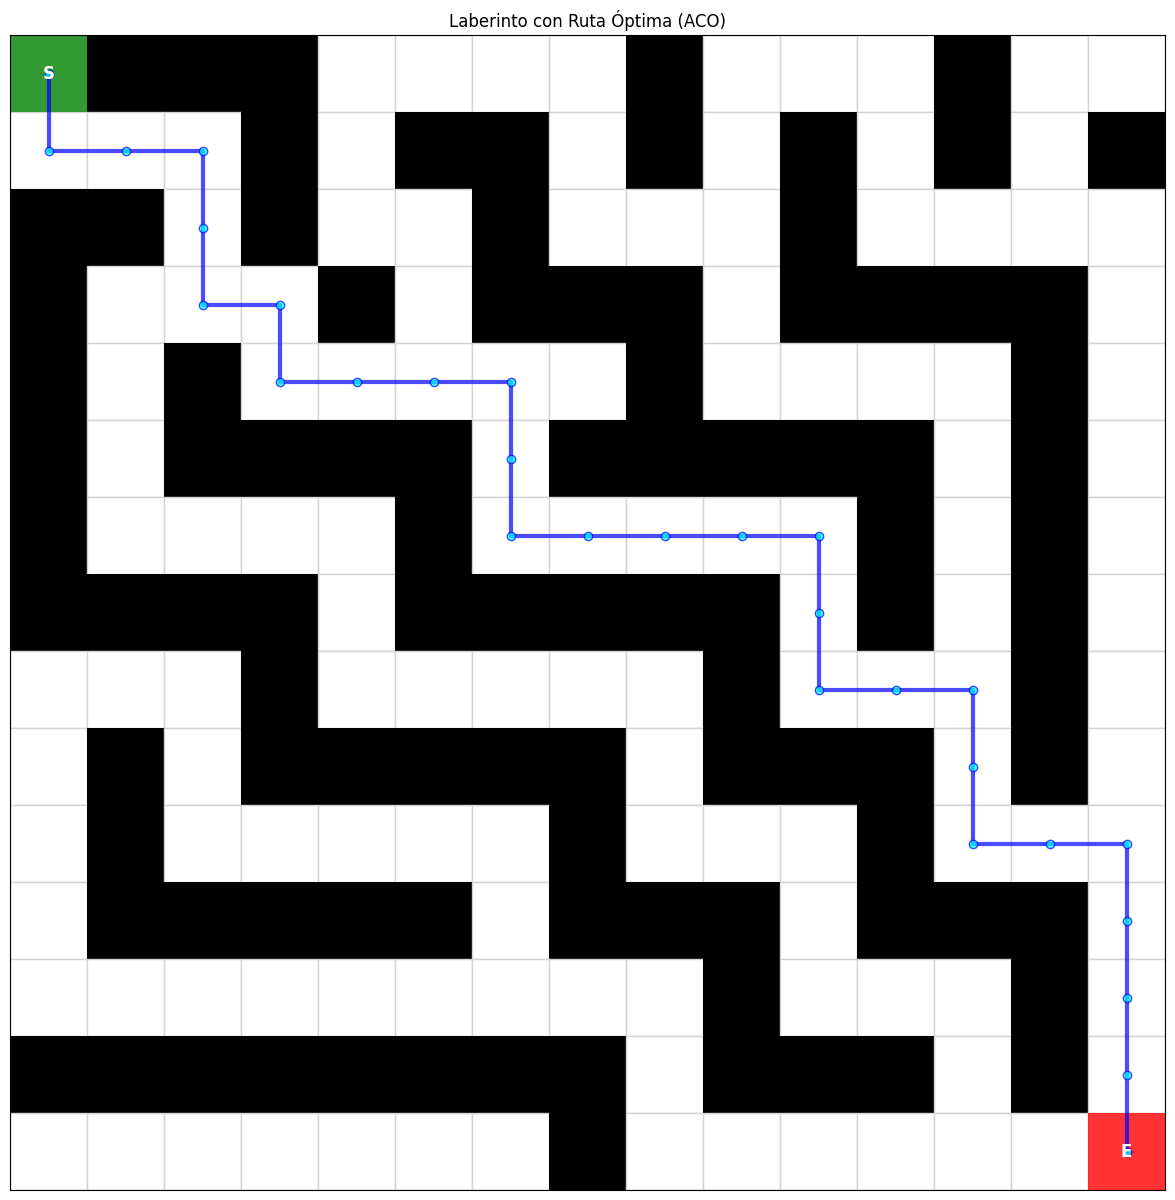

In [8]:
import matplotlib.pyplot as plt

def visualizar_laberinto_y_ruta(laberinto, ruta, inicio, fin):
    filas = len(laberinto)
    columnas = len(laberinto[0])

    fig, ax = plt.subplots(figsize=(columnas, filas))
    ax.set_aspect('equal')

    # Dibujar el laberinto
    for r in range(filas):
        for c in range(columnas):
            if laberinto[r][c] == 0:  # Pared
                ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor='black', edgecolor='none'))
            else:  # Camino
                ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor='white', edgecolor='lightgray'))

    # Dibujar la ruta
    if ruta:
        x_coords = [node[1] + 0.5 for node in ruta]
        y_coords = [node[0] + 0.5 for node in ruta]
        ax.plot(x_coords, y_coords, color='blue', linewidth=3, marker='o', markersize=6, markerfacecolor='cyan', markeredgecolor='blue', alpha=0.7)

    # Marcar el inicio y el fin
    if inicio:
        ax.add_patch(plt.Rectangle((inicio[1], inicio[0]), 1, 1, facecolor='green', edgecolor='none', alpha=0.8, label='Inicio'))
        ax.text(inicio[1] + 0.5, inicio[0] + 0.5, 'S', ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    if fin:
        ax.add_patch(plt.Rectangle((fin[1], fin[0]), 1, 1, facecolor='red', edgecolor='none', alpha=0.8, label='Fin'))
        ax.text(fin[1] + 0.5, fin[0] + 0.5, 'E', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

    ax.set_xlim(0, columnas)
    ax.set_ylim(filas, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Laberinto con Ruta Óptima (ACO)')
    plt.show()

mejor_ruta_encontrada = aco()

visualizar_laberinto_y_ruta(laberinto, mejor_ruta_encontrada, NODO_INICIO, NODO_FINAL)